# Markov Chain Monte Carlo

Besides Variational Inference, another possible way of approximating distributions is through Monte Carlo methods. These methods use sampling to approximate a distribution $p$.

In [1]:
%load_ext autoreload
%autoreload 2

import math
import random

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from pai import ising_model, metropolis_hastings

mpl.rc_file_defaults()

In [2]:
mean = 4.0
sigma = 2.0

for num_samples in [10, 100, 1000, 10_000]:
    s = 0
    for i in range(num_samples):
        s += random.gauss(mu=mean, sigma=sigma)
    print(f"Approximate mean: {s / num_samples}")

Approximate mean: 6.087952823857276
Approximate mean: 3.551169090752184
Approximate mean: 4.034517757956907
Approximate mean: 3.9894279351198647


The idea is that if we can draw samples from some distribution, then by the law of large numbers, we can approximate the true mean using these samples.

In [3]:
def q(x_input: float):
    """Gaussian mixture distribution.

    Args:
        x_input: Float location for which to calculate the likelihood.

    Returns:
        Function value at location ``x_input``.
    """
    return (
            0.3 * math.exp(-((x_input + 2) ** 2) / 2) +
            0.7 * math.exp(-((x_input - 2) ** 2) / 2)
    ) / math.sqrt(2 * math.pi)

In [4]:
x = 1.0
sigma = 1.0

x_samples = metropolis_hastings(x, sigma, q)

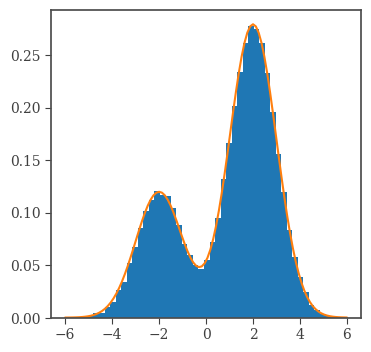

In [5]:
x = np.linspace(-6, 6, num=100)
y = np.array([q(x_i) for x_i in x])

fig, ax = plt.subplots(figsize=(4, 4))

ax.hist(x_samples, bins=50, density=True)
ax.plot(x, y)

plt.show()

## Ising Model

In [6]:
x_true = -np.ones((50, 50))
x_true[15:35, 15:35] = 1

x_observed = x_true.copy().ravel()
samples = np.random.choice(50 * 50, 200, replace=False)

mask_zero = x_observed[samples] == -1
mask_one = x_observed[samples] == 1
x_observed[samples] = np.where(mask_zero, 1, x_observed[samples])
x_observed[samples] = np.where(mask_one, -1, x_observed[samples])
x_observed = x_observed.reshape((50, 50))

In [7]:
x_restored = np.zeros((50, 50))
for i in range(50):
    for j in range(50):
        prob_pos = ising_model(
            x_observed, i, j,
            state=1.0, h=0.2
        )
        prob_neg = ising_model(
            x_observed, i, j,
            state=-1.0, h=0.2
        )
        if prob_pos > prob_neg:
            x_restored[i, j] = 1
        else:
            x_restored[i, j] = -1

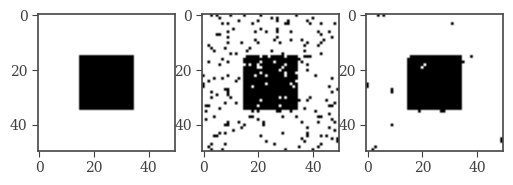

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(6, 4))

ax[0].imshow(x_true, cmap=ListedColormap(["white", "black"]))
ax[1].imshow(x_observed, cmap=ListedColormap(["white", "black"]))
ax[2].imshow(x_restored, cmap=ListedColormap(["white", "black"]))

plt.show()